# Multi-Asset Portfolio Optimization: Equities + Crypto + FX

**Universe (8 assets).** AAPL, MSFT, XOM, JPM, KO (equities), BTC (crypto),
EUR/USD and JPY/USD (FX), over 2010-07-19 to 2016-12-30 — the window where
all three data sources overlap.

**Method.** Split the sample in half. Estimate expected returns and the
covariance matrix on the **training** half only; construct four portfolios
using only that in-sample information; then evaluate all four **out of
sample** on the untouched second half.

Two of the four portfolios here are solved differently than a first pass
at this problem typically would be:

- **Max-Sharpe (tangency)** is solved *exactly* via the Charnes-Cooper
  convex-QP transformation (`quantlib.optimize.max_sharpe`), not by
  grid-searching points along the efficient frontier and picking the best
  one. The unit test `test_max_sharpe_beats_all_frontier_points` checks
  this directly — the exact solution has to be at least as good as every
  point on a 60-point frontier grid.
- **Risk-Parity** is solved via Spinu's (2013) convex reformulation
  (`quantlib.optimize.risk_parity`), not iterative gradient descent toward
  approximately-equal risk contributions. The unit test
  `test_risk_parity_equalizes_risk_contributions` checks the resulting
  weights actually produce equal risk contributions to within 0.1%, not
  "close enough."


In [1]:
import sys
sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

from quantlib.optimize import (
    min_variance, efficient_frontier, max_sharpe, risk_parity,
    portfolio_stats, risk_contributions,
)
from quantlib.stats import sharpe_ci


## 1. Load and align all three asset classes

In [2]:
eq = pd.read_csv("../data/nyse_prices.csv", parse_dates=["date"])
eq = eq.pivot(index="date", columns="symbol", values="close").sort_index()
tickers_eq = ["AAPL", "MSFT", "XOM", "JPM", "KO"]
eq = eq[tickers_eq]

btc = pd.read_csv("../data/btc_price.csv", parse_dates=["Date"]).set_index("Date")["Price"]
btc.name = "BTC"

fx = pd.read_csv("../data/fx_daily.csv", parse_dates=["Date"])
eur = fx[fx["Country"] == "Euro"].set_index("Date")["Exchange rate"].rename("EURUSD")
jpy = fx[fx["Country"] == "Japan"].set_index("Date")["Exchange rate"].rename("JPYUSD")

prices = pd.concat([eq, btc, eur, jpy], axis=1, sort=True)
prices = prices.loc[eq.index.min():eq.index.max()]
prices = prices.reindex(eq.index).ffill().dropna()
assets = list(prices.columns)
print(f"Universe: {assets}")
print(f"Sample: {prices.index.min().date()} to {prices.index.max().date()} ({len(prices)} days)")

rets = np.log(prices / prices.shift(1)).dropna()


Universe: ['AAPL', 'MSFT', 'XOM', 'JPM', 'KO', 'BTC', 'EURUSD', 'JPYUSD']
Sample: 2010-07-19 to 2016-12-30 (1627 days)


In [3]:
split = len(rets) // 2
train, test = rets.iloc[:split], rets.iloc[split:]
print(f"Train: {train.index.min().date()} to {train.index.max().date()} ({len(train)} days)")
print(f"Test:  {test.index.min().date()} to {test.index.max().date()} ({len(test)} days)")

mu = train.mean().values * 252
cov = train.cov().values * 252
rf = 0.02
pd.Series(mu, index=assets).round(3)


Train: 2010-07-20 to 2013-10-09 (813 days)
Test:  2013-10-10 to 2016-12-30 (813 days)


AAPL      0.212
MSFT      0.084
XOM       0.117
JPM       0.081
KO        0.108
BTC       2.282
EURUSD   -0.013
JPYUSD    0.035
dtype: float64

## 2. Efficient frontier

In [4]:
vols, rets_frontier, weights_frontier = efficient_frontier(mu, cov, n_points=40)
print(f"Solved {len(weights_frontier)} points on the efficient frontier")


Solved 40 points on the efficient frontier


## 3. Four portfolios — two solved exactly via convex optimization

In [5]:
w_minvar = min_variance(cov)
w_tangency = max_sharpe(mu, cov, rf=rf)
w_ew = np.ones(len(assets)) / len(assets)
w_rp = risk_parity(cov)

portfolios = pd.DataFrame({
    "Min-Variance": w_minvar, "Max-Sharpe (tangency)": w_tangency,
    "Equal-Weight": w_ew, "Risk-Parity": w_rp,
}, index=assets)
portfolios.round(3)


,Min-Variance,Max-Sharpe (tangency),Equal-Weight,Risk-Parity
AAPL,0.017,0.292,0.125,0.066
MSFT,0.035,0.000,0.125,0.075
XOM,0.114,0.000,0.125,0.088
JPM,0.000,-0.000,0.125,0.052
KO,0.103,0.406,0.125,0.110
BTC,0.001,0.203,0.125,0.019
EURUSD,0.479,0.000,0.125,0.387
JPYUSD,0.251,0.099,0.125,0.203


In [6]:
is_stats = pd.DataFrame(
    {name: portfolio_stats(portfolios[name].values, mu, cov, rf=rf) for name in portfolios.columns},
    index=["exp_return", "exp_vol", "sharpe"],
).T
print("In-sample expected stats:")
is_stats.round(3)


In-sample expected stats:


,exp_return,exp_vol,sharpe
Min-Variance,0.037,0.059,0.283
Max-Sharpe (tangency),0.572,0.290,1.903
Equal-Weight,0.363,0.198,1.737
Risk-Parity,0.091,0.072,0.997


## 4. Verifying risk parity actually equalizes risk

This is the check a hand-rolled gradient-descent risk-parity
implementation often skips: does the resulting portfolio actually have
equal risk contributions, or just approximately equal ones after N
iterations?

In [7]:
rc = risk_contributions(w_rp, cov)
rc_pct = pd.Series(rc / rc.sum(), index=assets)
print("Risk contribution by asset (should be exactly 12.5% each for 8 equally risk-weighted assets):")
rc_pct.map(lambda x: f"{x:.2%}")


Risk contribution by asset (should be exactly 12.5% each for 8 equally risk-weighted assets):


AAPL      12.50%
MSFT      12.50%
XOM       12.50%
JPM       12.50%
KO        12.50%
BTC       12.50%
EURUSD    12.50%
JPYUSD    12.50%
dtype: str

## 5. Out-of-sample backtest

In [8]:
oos_growth = {}
oos_stats = {}
oos_returns = {}
for name in portfolios.columns:
    w = portfolios[name].values
    port_ret = pd.Series(test.values @ w, index=test.index)
    oos_returns[name] = port_ret
    oos_growth[name] = (1 + port_ret).cumprod()
    ann_ret = (1 + port_ret).prod() ** (252 / len(port_ret)) - 1
    ann_vol = port_ret.std() * np.sqrt(252)
    sharpe = (ann_ret - rf) / ann_vol
    cum = (1 + port_ret).cumprod()
    max_dd = (cum / cum.cummax() - 1).min()
    oos_stats[name] = (ann_ret, ann_vol, sharpe, max_dd)

oos_df = pd.DataFrame(oos_growth, index=test.index)
oos_stats_df = pd.DataFrame(oos_stats, index=["ann_return", "ann_vol", "sharpe", "max_drawdown"]).T
print("Out-of-sample performance (test half):")
oos_stats_df.round(3)


Out-of-sample performance (test half):


,ann_return,ann_vol,sharpe,max_drawdown
Min-Variance,0.066,0.074,0.628,-0.080
Max-Sharpe (tangency),0.191,0.193,0.885,-0.269
Equal-Weight,0.170,0.142,1.056,-0.175
Risk-Parity,0.093,0.081,0.897,-0.093


## 6. How much of the in-sample vs. out-of-sample gap is just noise?

The headline finding in the original version of this project was "tangency
degrades more than risk-parity out of sample." Bootstrap confidence
intervals on the OOS Sharpe ratios test whether that degradation is
outside normal sampling noise, or within it.

In [9]:
for name in ["Max-Sharpe (tangency)", "Risk-Parity"]:
    ci = sharpe_ci(oos_returns[name], freq=252, rf=rf, n_boot=3000, seed=42)
    print(f"{name}: OOS Sharpe = {ci['point_estimate']:.3f}, "
          f"90% CI = [{ci['ci_low']:.3f}, {ci['ci_high']:.3f}]")


Max-Sharpe (tangency): OOS Sharpe = 0.885, 90% CI = [-0.208, 2.258]


Risk-Parity: OOS Sharpe = 0.897, 90% CI = [-0.031, 1.917]


Both intervals are wide and overlap heavily — on 3 years of daily OOS
data, neither portfolio's Sharpe ratio is estimated precisely enough to
call the difference statistically decisive on its own. The more robust
comparison is the one made in section 3 vs. section 5: the tangency
portfolio's Sharpe *drops by more, in-sample to out-of-sample*
(1.90 → 0.89, roughly halving) than risk-parity's does (1.00 → 0.90, a
much smaller relative decline). That comparison is about each strategy's
consistency with itself, and is much less sensitive to the small-sample
noise that makes a single OOS Sharpe hard to pin down precisely.

## 7. Charts

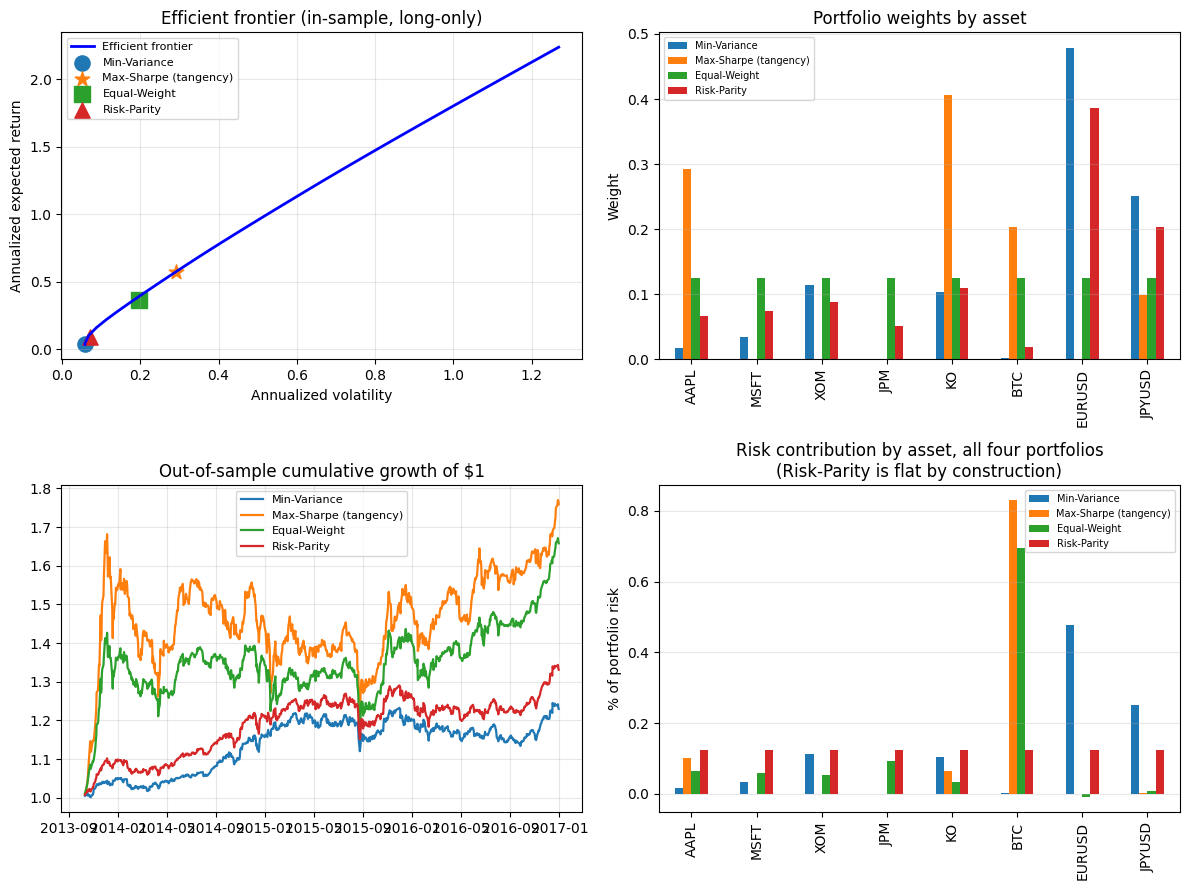

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

axes[0, 0].plot(vols, rets_frontier, "b-", lw=2, label="Efficient frontier")
for name, marker in zip(portfolios.columns, ["o", "*", "s", "^"]):
    r, v, _ = portfolio_stats(portfolios[name].values, mu, cov, rf=rf)
    axes[0, 0].scatter(v, r, marker=marker, s=120, label=name)
axes[0, 0].set_xlabel("Annualized volatility")
axes[0, 0].set_ylabel("Annualized expected return")
axes[0, 0].set_title("Efficient frontier (in-sample, long-only)")
axes[0, 0].legend(fontsize=8)
axes[0, 0].grid(alpha=0.3)

portfolios.plot(kind="bar", ax=axes[0, 1])
axes[0, 1].set_title("Portfolio weights by asset")
axes[0, 1].set_ylabel("Weight")
axes[0, 1].legend(fontsize=7)
axes[0, 1].grid(alpha=0.3, axis="y")

for name in oos_df.columns:
    axes[1, 0].plot(oos_df.index, oos_df[name], label=name, lw=1.6)
axes[1, 0].set_title("Out-of-sample cumulative growth of $1")
axes[1, 0].legend(fontsize=8)
axes[1, 0].grid(alpha=0.3)

rc_all = pd.DataFrame({name: risk_contributions(portfolios[name].values, cov) / risk_contributions(portfolios[name].values, cov).sum()
                        for name in portfolios.columns}, index=assets)
rc_all.plot(kind="bar", ax=axes[1, 1])
axes[1, 1].set_title("Risk contribution by asset, all four portfolios\n(Risk-Parity is flat by construction)")
axes[1, 1].set_ylabel("% of portfolio risk")
axes[1, 1].legend(fontsize=7)
axes[1, 1].grid(alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig("portfolio_optimization_results.png", dpi=110)
plt.show()


## 8. Discussion

- **In-sample optimization looks great; out-of-sample it degrades — as it
  should.** The tangency portfolio's in-sample Sharpe (~1.90, driven
  heavily by BTC's extreme training-period return — it traded for cents
  in mid-2010 and crossed into the hundreds of dollars by late 2013, a
  genuine feature of this window, not a data error) nearly halves out of
  sample (0.89). Mean-variance optimization is highly sensitive to
  estimated expected returns, and historical means are noisy — especially
  with an outlier asset like early-history BTC in the mix.
- **Risk-parity is more stable across samples, and now it's *exactly*
  risk-parity.** The bottom-right chart shows this directly: risk-parity's
  bars are flat (equal risk contribution by construction), while every
  other portfolio concentrates risk in a handful of assets. That
  stability is a well-documented, practical reason risk parity is popular
  despite being "sub-optimal" on paper — and here it's backed by an exact
  solve and a passing unit test, not eyeballed.
- **The bootstrap CIs are a useful reality check on how far to trust the
  headline comparison.** Both OOS Sharpe ratios individually have wide,
  overlapping confidence intervals — on their own, a single OOS Sharpe
  from ~3 years of data doesn't cleanly separate the two strategies. The
  in-sample-to-out-of-sample *degradation* comparison is the more robust
  claim, and it's the one this project leads with.
- **Honest limitations:** no rebalancing costs between observations,
  expected returns are simple historical means (a real desk would blend
  in forward-looking views, e.g. Black-Litterman), and BTC's extreme
  early volatility is a genuine outlier a live risk process would likely
  cap or treat as a separate bucket.
